In [3]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore") 

In [4]:
df = pd.read_csv('train.csv')
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales
0,1,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600
1,2,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400
2,3,CA-2017-138688,12/06/2017,16/06/2017,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036.0,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200
3,4,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775
4,5,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680


In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 9800 entries, 0 to 9799
Data columns (total 18 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9800 non-null   int64  
 1   Order ID       9800 non-null   str    
 2   Order Date     9800 non-null   str    
 3   Ship Date      9800 non-null   str    
 4   Ship Mode      9800 non-null   str    
 5   Customer ID    9800 non-null   str    
 6   Customer Name  9800 non-null   str    
 7   Segment        9800 non-null   str    
 8   Country        9800 non-null   str    
 9   City           9800 non-null   str    
 10  State          9800 non-null   str    
 11  Postal Code    9789 non-null   float64
 12  Region         9800 non-null   str    
 13  Product ID     9800 non-null   str    
 14  Category       9800 non-null   str    
 15  Sub-Category   9800 non-null   str    
 16  Product Name   9800 non-null   str    
 17  Sales          9800 non-null   float64
dtypes: float64(2), int6

*   What are the top 3 highest-selling product categories in this dataset based on total sales?

In [6]:
category_sales = df.groupby("Category")['Sales'].sum().sort_values(ascending=False)
category_sales

Category
Technology         827455.8730
Furniture          728658.5757
Office Supplies    705422.3340
Name: Sales, dtype: float64

<Axes: xlabel='Category', ylabel='Sales'>

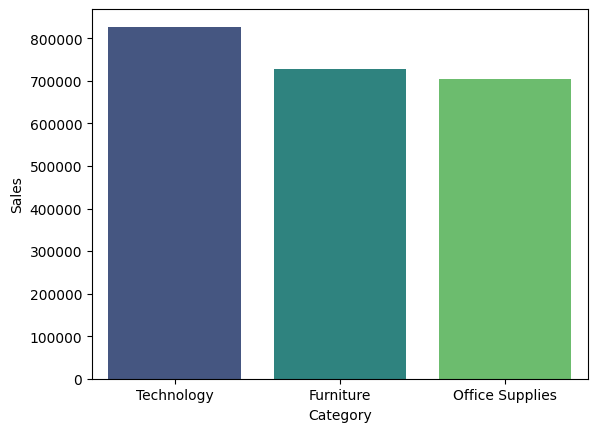

In [7]:
sns.barplot(category_sales,palette='viridis')

*   Which City generated the most revenue (highest sum of sales), and what was its total sales amount?

In [8]:
cities_sales = df.groupby("City")["Sales"].sum().sort_values(ascending=False).head(1)
cities_sales

City
New York City    252462.547
Name: Sales, dtype: float64

<Axes: xlabel='Sales', ylabel='City'>

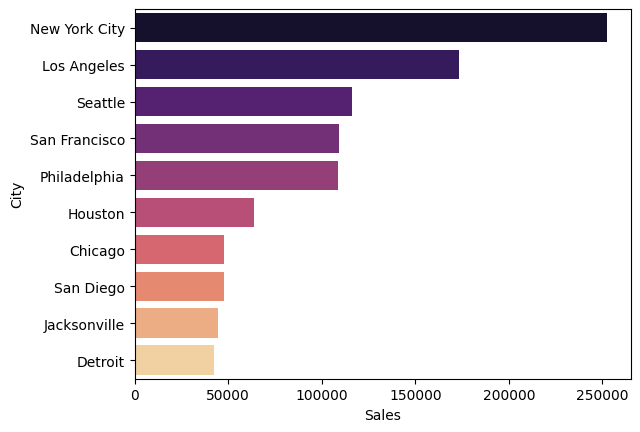

In [9]:
cities_sales = df.groupby("City")["Sales"].sum().sort_values(ascending=False).head(10).reset_index()
sns.barplot(x='Sales',y='City',data=cities_sales,palette='magma')

*   Which Ship Mode is the most preferred by customers (meaning, which shipping method appears the most times in the dataset)?

In [10]:
pref_ship = df['Ship Mode'].value_counts().reset_index()
pref_ship

,Ship Mode,count
0,Standard Class,5859
1,Second Class,1902
2,First Class,1501
3,Same Day,538


Text(0.5, 1.0, 'Prefered Shiping Method')

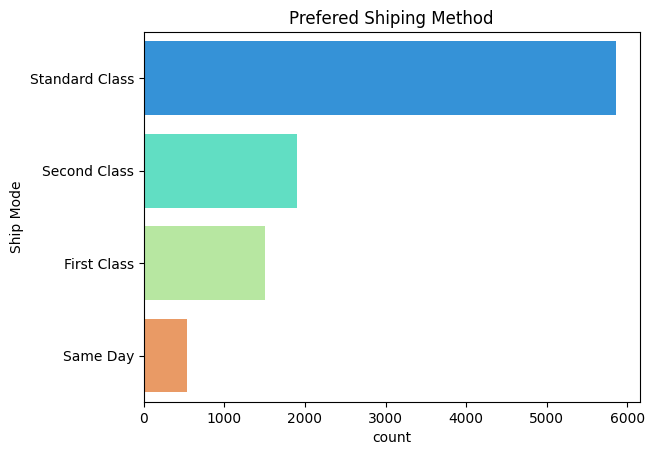

In [11]:
sns.barplot(x='count',y='Ship Mode',data=pref_ship,palette='rainbow')
plt.title('Prefered Shiping Method')

*   In which Year did the superstore achieve its highest total sales revenue?

In [12]:
df['Order Date'] = pd.to_datetime(df['Order Date'],format='mixed', dayfirst= True)
df['Years'] = df['Order Date'].dt.year
yearly_sales = df.groupby('Years')['Sales'].sum().sort_values(ascending=False).reset_index()
yearly_sales

,Years,Sales
0,2018,722052.0192
1,2017,600192.5500
2,2015,479856.2081
3,2016,459436.0054


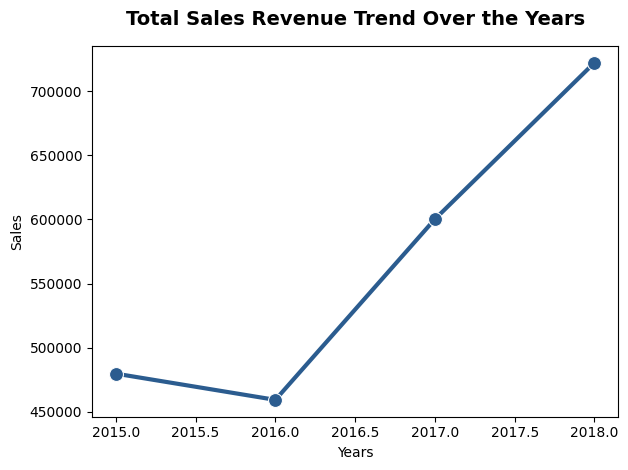

In [13]:
sns.lineplot(
    x= 'Years',
    y='Sales',
    data=yearly_sales,
    marker ='o',
    markersize=10,
    linewidth =3,
    color = '#2b5c8f'
)
plt.title('Total Sales Revenue Trend Over the Years', fontsize=14, fontweight='bold', pad=15)
plt.tight_layout()
plt.show()

*   Which Product Sub-Category generated the highest total sales, and which one was the least popular (lowest total sales)?

In [14]:
h_l_sc = df.groupby('Sub-Category')['Sales'].sum().sort_values(ascending=False).reset_index()
h_l_sc

,Sub-Category,Sales
0,Phones,327782.4480
1,Chairs,322822.7310
2,Storage,219343.3920
3,Tables,202810.6280
4,Binders,200028.7850
5,Machines,189238.6310
6,Accessories,164186.7000
7,Copiers,146248.0940
8,Bookcases,113813.1987
9,Appliances,104618.4030


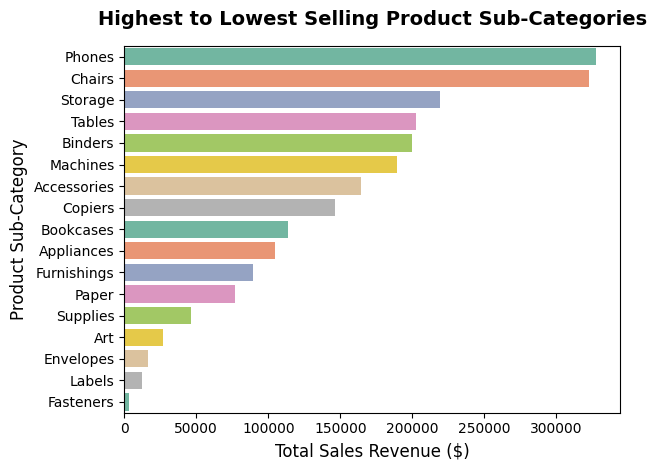

In [15]:
sns.barplot(x='Sales',y='Sub-Category',data=h_l_sc,palette='Set2')
plt.title('Highest to Lowest Selling Product Sub-Categories', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Total Sales Revenue ($)', fontsize=12)
plt.ylabel('Product Sub-Category', fontsize=12)
plt.tight_layout()
plt.show()

*   We saw that overall sales grew massively from 2016 to 2018. But did all product categories grow equally?

In [19]:
category_trends = df.groupby(['Years','Category'])['Sales'].sum().reset_index()
category_trends

,Years,Category,Sales
0,2015,Furniture,156477.8811
1,2015,Office Supplies,149512.8200
2,2015,Technology,173865.5070
3,2016,Furniture,164053.8674
4,2016,Office Supplies,133124.4070
5,2016,Technology,162257.7310
6,2017,Furniture,195813.0400
7,2017,Office Supplies,182417.5660
8,2017,Technology,221961.9440
9,2018,Furniture,212313.7872


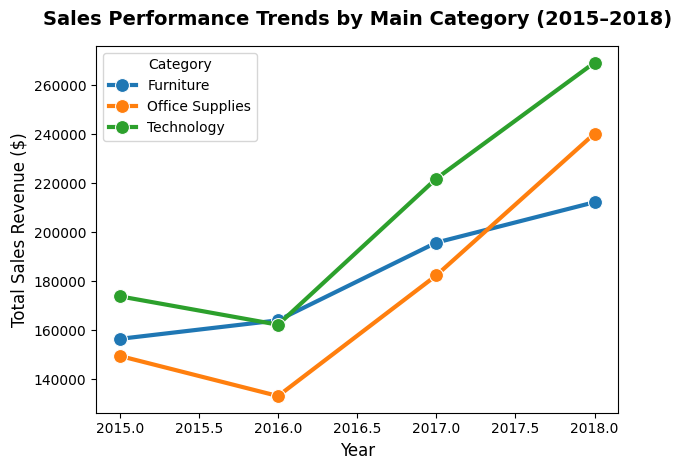

In [ ]:
sns.lineplot(
    x = 'Years_sale',
    y = 'Sales',
    hue='Category',
    data = category_trends,
    marker = 'o',
    markersize = 10,
    linewidth = 3
)
plt.title('Sales Performance Trends by Main Category (2015–2018)', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Year', fontsize=12)
plt.ylabel('Total Sales Revenue ($)', fontsize=12)

plt.tight_layout()
plt.show()

*   Which Top 5 Customers (Customer Name) generated the absolute highest total sales revenue for the superstore?

In [22]:
top_5_customers = df.groupby('Customer Name')['Sales'].sum().sort_values(ascending=False).reset_index().head(5)
top_5_customers

,Customer Name,Sales
0,Sean Miller,25043.050
1,Tamara Chand,19052.218
2,Raymond Buch,15117.339
3,Tom Ashbrook,14595.620
4,Adrian Barton,14473.571


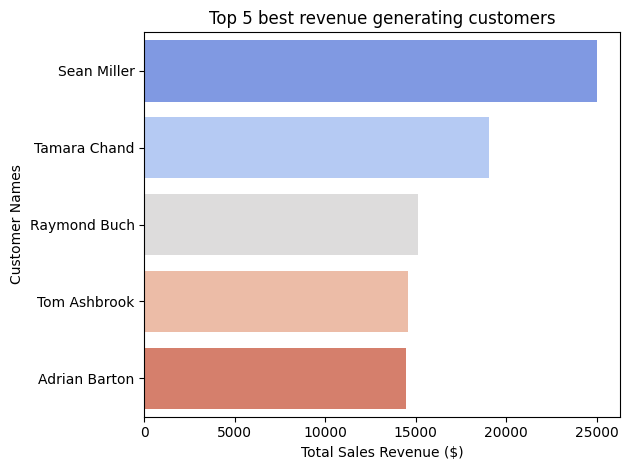

In [38]:
sns.barplot(x='Sales',y='Customer Name',data=top_5_customers,palette='coolwarm')
plt.title('Top 5 best revenue generating customers')
plt.xlabel("Total Sales Revenue ($)")
plt.ylabel("Customer Names")
plt.tight_layout()
plt.show()

*   Calculate the average number of days it takes to ship an order for each Shipping Mode (Ship Mode)

In [34]:
df['Ship Date'] = pd.to_datetime(df['Ship Date'],format='mixed',dayfirst=True)


In [42]:
df["Days_to_ship"] = (df['Ship Date'] - df['Order Date']).dt.days
shiping_speeds = df.groupby('Ship Mode')['Days_to_ship'].mean().sort_values().reset_index()
shiping_speeds.round(2)

,Ship Mode,Days_to_ship
0,Same Day,0.04
1,First Class,2.18
2,Second Class,3.25
3,Standard Class,5.01


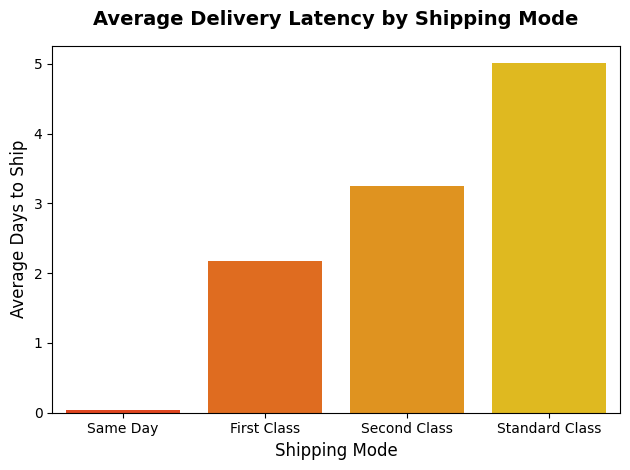

In [43]:
sns.barplot(x='Ship Mode', y = 'Days_to_ship', data= shiping_speeds,palette='autumn')
plt.title('Average Delivery Latency by Shipping Mode', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Shipping Mode', fontsize=12)
plt.ylabel('Average Days to Ship', fontsize=12)

plt.tight_layout()
plt.show()

*   Which customer Segment (Consumer, Corporate, or Home Office) brings in the highest amount of total sales, and what percentage of overall sales does it represent?

In [ ]:
segment_wise_revenue = df.groupby('Segment')['Sales'].sum().sort_values(ascending=False).reset_index()
segment_wise_revenue

,Segment,Sales
0,Consumer,1.148061e+06
1,Corporate,6.884941e+05
2,Home Office,4.249822e+05


In [49]:
# Percentage
total_sales = df["Sales"].sum()
segment_wise_revenue['Percentage'] = (segment_wise_revenue['Sales'] / total_sales) * 100
segment_wise_revenue

,Segment,Sales,Percentage
0,Consumer,1.148061e+06,50.764619
1,Corporate,6.884941e+05,30.443638
2,Home Office,4.249822e+05,18.791743


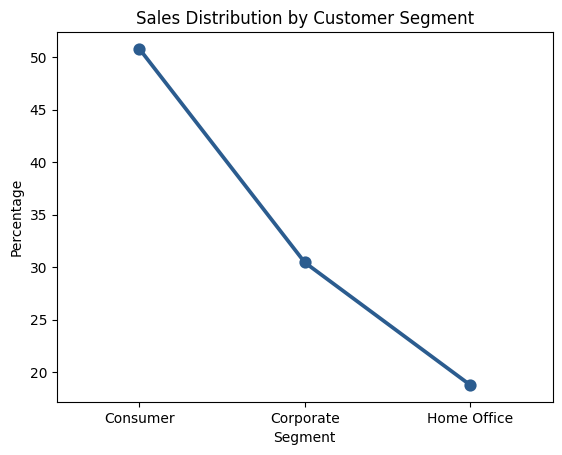

In [55]:
sns.pointplot(
    x = 'Segment',
    y = 'Percentage',
    data = segment_wise_revenue,
    marker = 'o',
    color='#2b5c8f',
    linestyles = '-'
)
plt.title('Sales Distribution by Customer Segment')
plt.show()

*   We know which cities perform well, but let's look at the bigger picture. Break down the Total Sales by Region, but sub-divided by the Product Category to see which region loves which products the most.

In [65]:
region_sales = df.groupby(["Region","Sub-Category"])['Sales'].sum().unstack()
region_sales


Sub-Category,Accessories,Appliances,Art,Binders,Bookcases,Chairs,Copiers,Envelopes,Fasteners,Furnishings,Labels,Machines,Paper,Phones,Storage,Supplies,Tables
Region,,,,,,,,,,,,,,,,,
Central,32742.302,21176.833,5746.188,56865.012,23773.7112,82372.776,37259.570,4537.304,769.570,15016.004,2435.536,26797.384,17184.988,71939.952,45407.440,9467.372,39154.971
East,43906.238,34119.078,7430.974,51255.775,43819.3340,95687.509,53219.462,4138.246,819.718,28145.326,2554.914,66106.165,19538.114,99884.662,69428.656,10655.336,38809.219
South,26906.154,19525.326,4510.424,36734.365,10899.3620,44739.246,9299.756,3345.556,503.316,17062.660,2344.180,53890.960,13891.576,58098.338,35251.100,8318.928,43830.212
West,60632.006,29797.166,9017.824,55173.633,35320.7915,100023.200,46469.306,4106.940,909.356,28988.028,5013.096,42444.122,26213.626,97859.496,69256.196,17978.672,81016.226


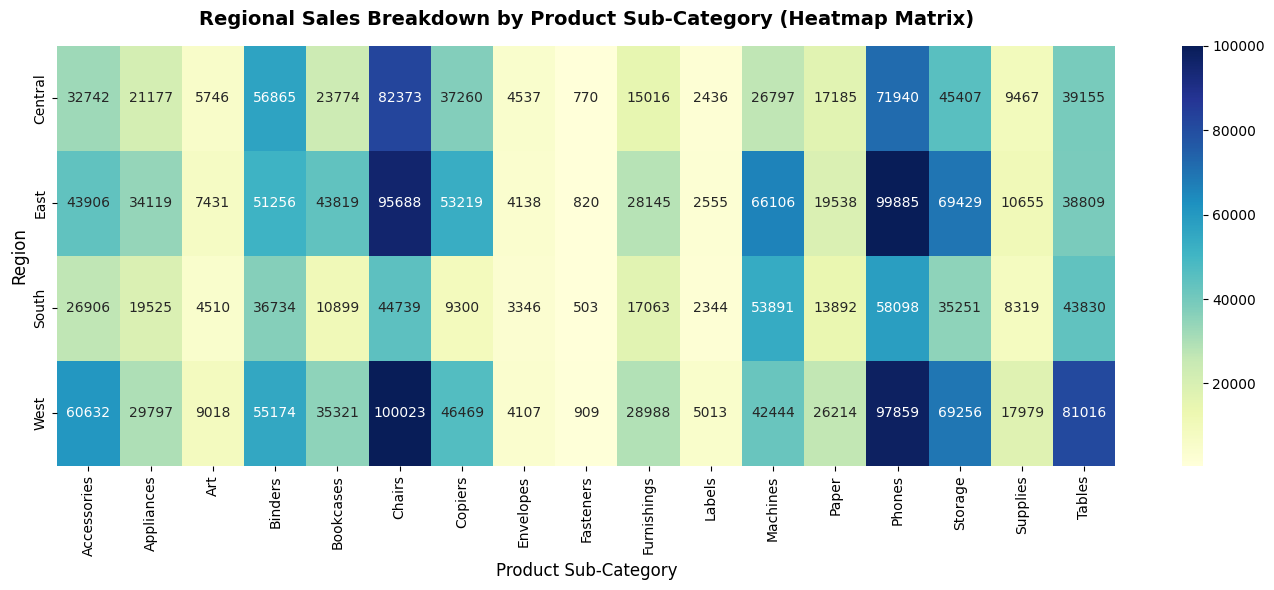

In [70]:
plt.figure(figsize=(14, 6))

# 3. Create the heatmap
# annot=True shows the dollar amounts
# fmt=".0f" rounds to whole dollars to keep it clean
# cmap="YlGnBu" gives it a beautiful yellow-to-blue gradient
sns.heatmap(region_sales, annot=True, fmt=".0f", cmap="YlGnBu", cbar=True)

# 4. Final labels
plt.title('Regional Sales Breakdown by Product Sub-Category (Heatmap Matrix)', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Product Sub-Category', fontsize=12)
plt.ylabel('Region', fontsize=12)

plt.tight_layout()
plt.show()

# GOOD-WORK